## EDA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


Bad key "text.kerning_factor" on line 4 in
C:\Users\imrulhuda\Anaconda3\envs\tone\lib\site-packages\matplotlib\mpl-data\stylelib\_classic_test_patch.mplstyle.
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.1.3/matplotlibrc.template
or from the matplotlib source distribution


First thought -  it is good idea to spend some time on looking at the top and bottom data. We will do some sanity check on the other later.

In [2]:
top = pd.read_csv('train\\top.csv', index_col=0)
bottom = pd.read_csv('train\\bottom.csv', index_col=0)

In [3]:
top.shape, bottom.shape

((1025, 195), (1025, 178))

In [4]:
top.columns

Index(['0.0', '23.219954648526077', '46.439909297052154', '69.65986394557822',
       '92.87981859410431', '116.09977324263039', '139.31972789115645',
       '162.53968253968253', '185.75963718820861', '208.9795918367347',
       ...
       '4295.691609977324', '4318.91156462585', '4342.131519274377',
       '4365.351473922902', '4388.571428571428', '4411.791383219955',
       '4435.011337868481', '4458.231292517006', '4481.4512471655335',
       '4504.671201814059'],
      dtype='object', length=195)

In [7]:
# looks like equal distance in time. lets confirm.
# this will give us the sampling rate
import numpy as np
arr = np.array([float(i) for i in top.columns])
diffs = np.diff(arr)
print(diffs)

[23.21995465 23.21995465 23.21995465 23.21995465 23.21995465 23.21995465
 23.21995465 23.21995465 23.21995465 23.21995465 23.21995465 23.21995465
 23.21995465 23.21995465 23.21995465 23.21995465 23.21995465 23.21995465
 23.21995465 23.21995465 23.21995465 23.21995465 23.21995465 23.21995465
 23.21995465 23.21995465 23.21995465 23.21995465 23.21995465 23.21995465
 23.21995465 23.21995465 23.21995465 23.21995465 23.21995465 23.21995465
 23.21995465 23.21995465 23.21995465 23.21995465 23.21995465 23.21995465
 23.21995465 23.21995465 23.21995465 23.21995465 23.21995465 23.21995465
 23.21995465 23.21995465 23.21995465 23.21995465 23.21995465 23.21995465
 23.21995465 23.21995465 23.21995465 23.21995465 23.21995465 23.21995465
 23.21995465 23.21995465 23.21995465 23.21995465 23.21995465 23.21995465
 23.21995465 23.21995465 23.21995465 23.21995465 23.21995465 23.21995465
 23.21995465 23.21995465 23.21995465 23.21995465 23.21995465 23.21995465
 23.21995465 23.21995465 23.21995465 23.21995465 23

In [8]:
# not equal time length
len(top.columns), len(bottom.columns)

(195, 178)

In [9]:
bottom.columns

Index(['0.0', '23.219954648526077', '46.439909297052154', '69.65986394557822',
       '92.87981859410431', '116.09977324263039', '139.31972789115645',
       '162.53968253968253', '185.75963718820861', '208.9795918367347',
       ...
       '3900.9523809523807', '3924.172335600907', '3947.3922902494332',
       '3970.6122448979595', '3993.8321995464853', '4017.052154195011',
       '4040.272108843538', '4063.492063492063', '4086.71201814059',
       '4109.931972789115'],
      dtype='object', length=178)

In [10]:
top.index

Float64Index([             0.0,    10.7666015625,     21.533203125,
                 32.2998046875,      43.06640625,    53.8330078125,
                  64.599609375,    75.3662109375,       86.1328125,
                 96.8994140625,
              ...
              10928.1005859375,    10938.8671875, 10949.6337890625,
               10960.400390625, 10971.1669921875,   10981.93359375,
              10992.7001953125,  11003.466796875, 11014.2333984375,
                       11025.0],
             dtype='float64', name='frequency', length=1025)

In [11]:
bottom.index

Float64Index([             0.0,    10.7666015625,     21.533203125,
                 32.2998046875,      43.06640625,    53.8330078125,
                  64.599609375,    75.3662109375,       86.1328125,
                 96.8994140625,
              ...
              10928.1005859375,    10938.8671875, 10949.6337890625,
               10960.400390625, 10971.1669921875,   10981.93359375,
              10992.7001953125,  11003.466796875, 11014.2333984375,
                       11025.0],
             dtype='float64', name='frequency', length=1025)

In [13]:
# looks like rows are all same frequency. Lets confirm
sum(top.index != bottom.index)

0

In [14]:
# lets convert the str to numeric. Thinking about forcing to int. May do it later. Lets keep float now.
top.index   = top.index.astype(float)
top.columns = top.columns.astype(float)
bottom.index   = bottom.index.astype(float)
bottom.columns = bottom.columns.astype(float)

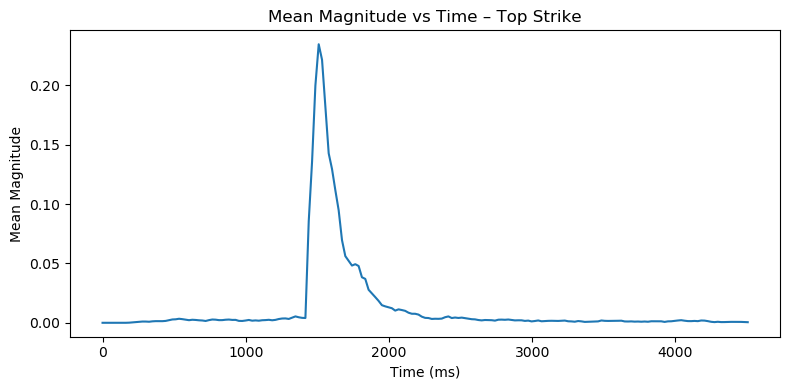

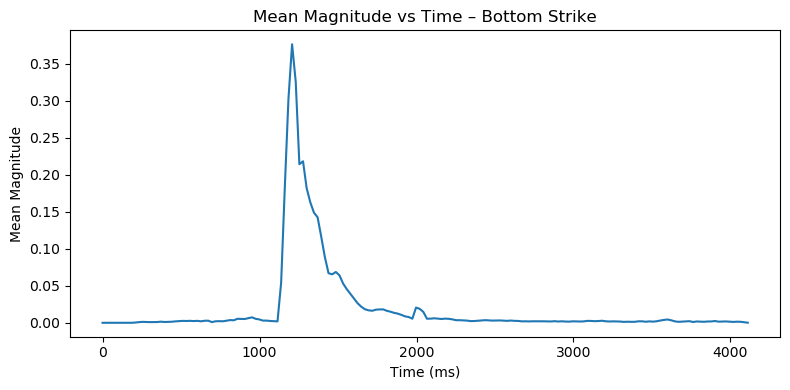

In [16]:
# Lets get the mean energy over time
# The x-axis is not informative because time of hit during recording is not important
# in y-axis we can clearly see higher energy in bottom hit.
# using the word "energy" loosely here
top_mean    = top.mean(axis=0)
bottom_mean = bottom.mean(axis=0)

plt.figure(figsize=(8, 4))
plt.plot(top_mean.index, top_mean.values, label='Top')
plt.title('Mean Magnitude vs Time – Top Strike')
plt.xlabel('Time (ms)')
plt.ylabel('Mean Magnitude')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(bottom_mean.index, bottom_mean.values, label='Bottom')
plt.title('Mean Magnitude vs Time – Bottom Strike')
plt.xlabel('Time (ms)')
plt.ylabel('Mean Magnitude')
plt.tight_layout()
plt.show()

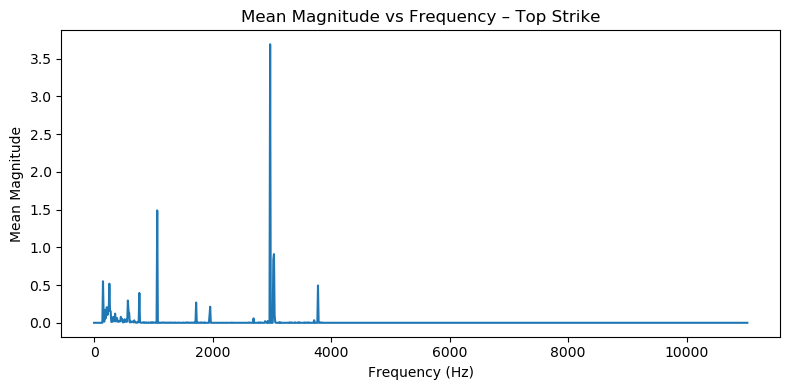

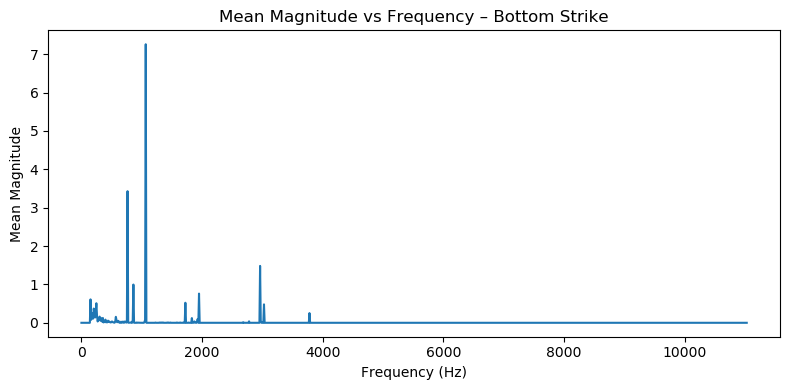

In [17]:
# Lets get the mean energy over different frequencies
# we can see that different frequecies get activated for top vs bottom hit.
# top one has a key frequency around 3000
# bottom one has a key frequency around 1000
# not reading too much into the y axis now. "key frequency" is also may not be a correct scientific term.
top_mean    = top.mean(axis=1)
bottom_mean = bottom.mean(axis=1)

plt.figure(figsize=(8, 4))
plt.plot(top_mean.index, top_mean.values, label='Top')
plt.title('Mean Magnitude vs Frequency – Top Strike')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Mean Magnitude')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(bottom_mean.index, bottom_mean.values, label='Bottom')
plt.title('Mean Magnitude vs Frequency – Bottom Strike')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Mean Magnitude')
plt.tight_layout()
plt.show()

Since I have `librosa` install already. I am going to check the spectogram with `librosa`. The following graphs confirm our observation above that 

1) the top‐strike exhibits stronger energy peaks in the higher-frequency bins, whereas the bottom-strike shows comparatively lower magnitudes in those same high-frequency regions.

2) Also noticing that the most prominent Hz in the top one stays "activated" (lit up) i.e. continuous over time. But the bottom one has a dashed pattern. This might be useful. May be different parts of the water bottle has different melalic properties.

In [18]:
import librosa
import librosa.display

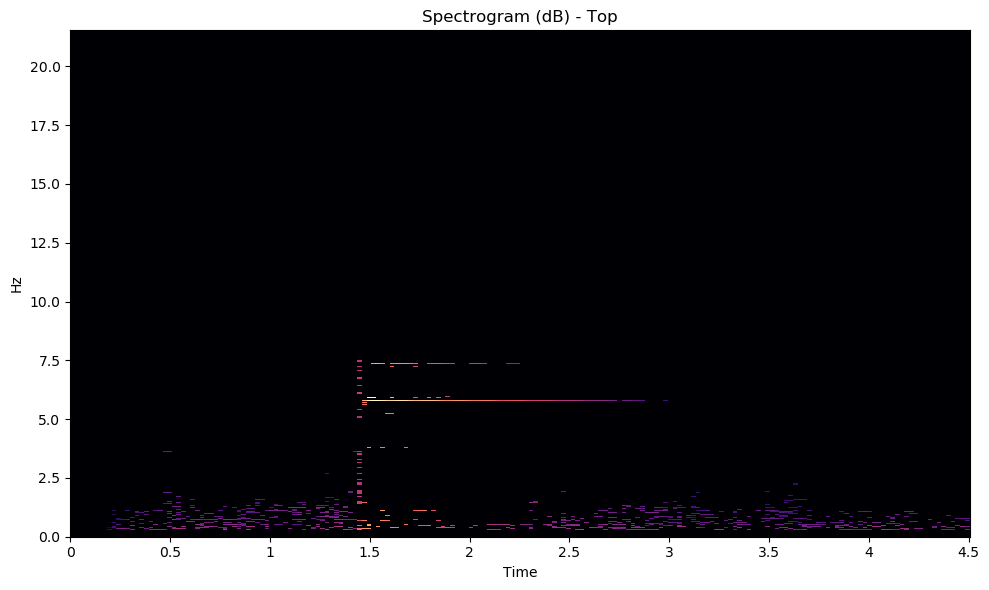

In [19]:
times = top.columns.astype(float)
freqs = top.index.astype(float)                     
spect_db = librosa.amplitude_to_db(top.values, ref=np.max)

sr = 1000.0 / np.mean(np.diff(times))                  
hop_length = 1                       

plt.figure(figsize=(10, 6))
librosa.display.specshow(
    spect_db,
    sr=sr,
    hop_length=hop_length,
    x_axis='time',
    y_axis='hz'
)
plt.title("Spectrogram (dB) - Top")
plt.tight_layout()
plt.show()

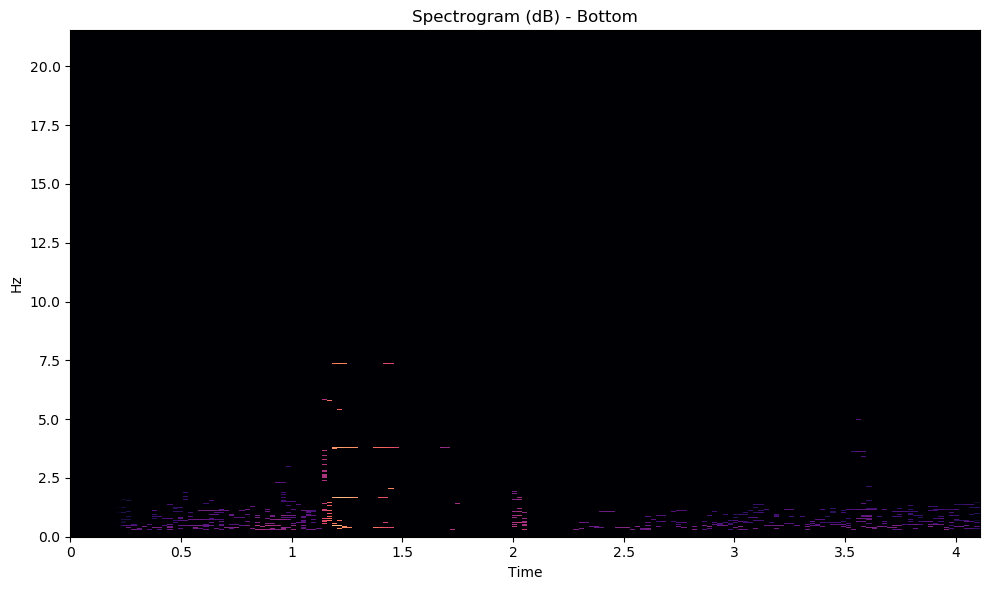

In [20]:
times = bottom.columns.astype(float)
freqs = bottom.index.astype(float)                     
spect_db = librosa.amplitude_to_db(bottom.values, ref=np.max)

sr = 1000.0 / np.mean(np.diff(times))                  
hop_length = 1                       

plt.figure(figsize=(10, 6))
librosa.display.specshow(
    spect_db,
    sr=sr,
    hop_length=hop_length,
    x_axis='time',
    y_axis='hz'
)
plt.title("Spectrogram (dB) - Bottom")
plt.tight_layout()
plt.show()

## Classification Stratgey:

This is an unsupervised learning problem. We do not have test data. Only one example from each class which is mostly for EDA. I am thinking several ways we can do this.

1. Distance based approach: We can define a distance metric (such as cosign similarity) for spectograms and measure the distance of each unlabeled from top and bottom. May have to reduce the spectogram to 1d first. 

2. We can play with some features (which I used recently for a paper). Such as Spectral bandwidth, Spectral centroid. MFCC, etc. and follow a cutoff based approach. But my project was on speech, so I need time to figure out which feature is not related in this problem. 

3. Threshold based approach: We can compute centroid or dominant peak in Hz and compare them to the ones from top and bottom. Decide on a threshold and yield result.

4. PCA/t-SNE followed by Clustering. I will hope that the top and bottom clearly falls in two different cluster. They generate nice plot. Define a gray zone for `None`.

5. Do a Decision Tree on the features from 1 and/or 2. 


*Afterthought: I tried PCA approach. Actually it may be a good idea here with the small number of files. But with lots of file, I think diving into the scientific features is the best way. So, avoiding the PCA.*

Lets do one more plot before deciding on a stratgey. This plot will require opening in a new tab for better viewing. Based on the inspection, given the time constraint, it is better to use a simple stratgey. We will also table the "dashed pattern" idea for now. Needs further exploration. For now, we will go with No. 3.

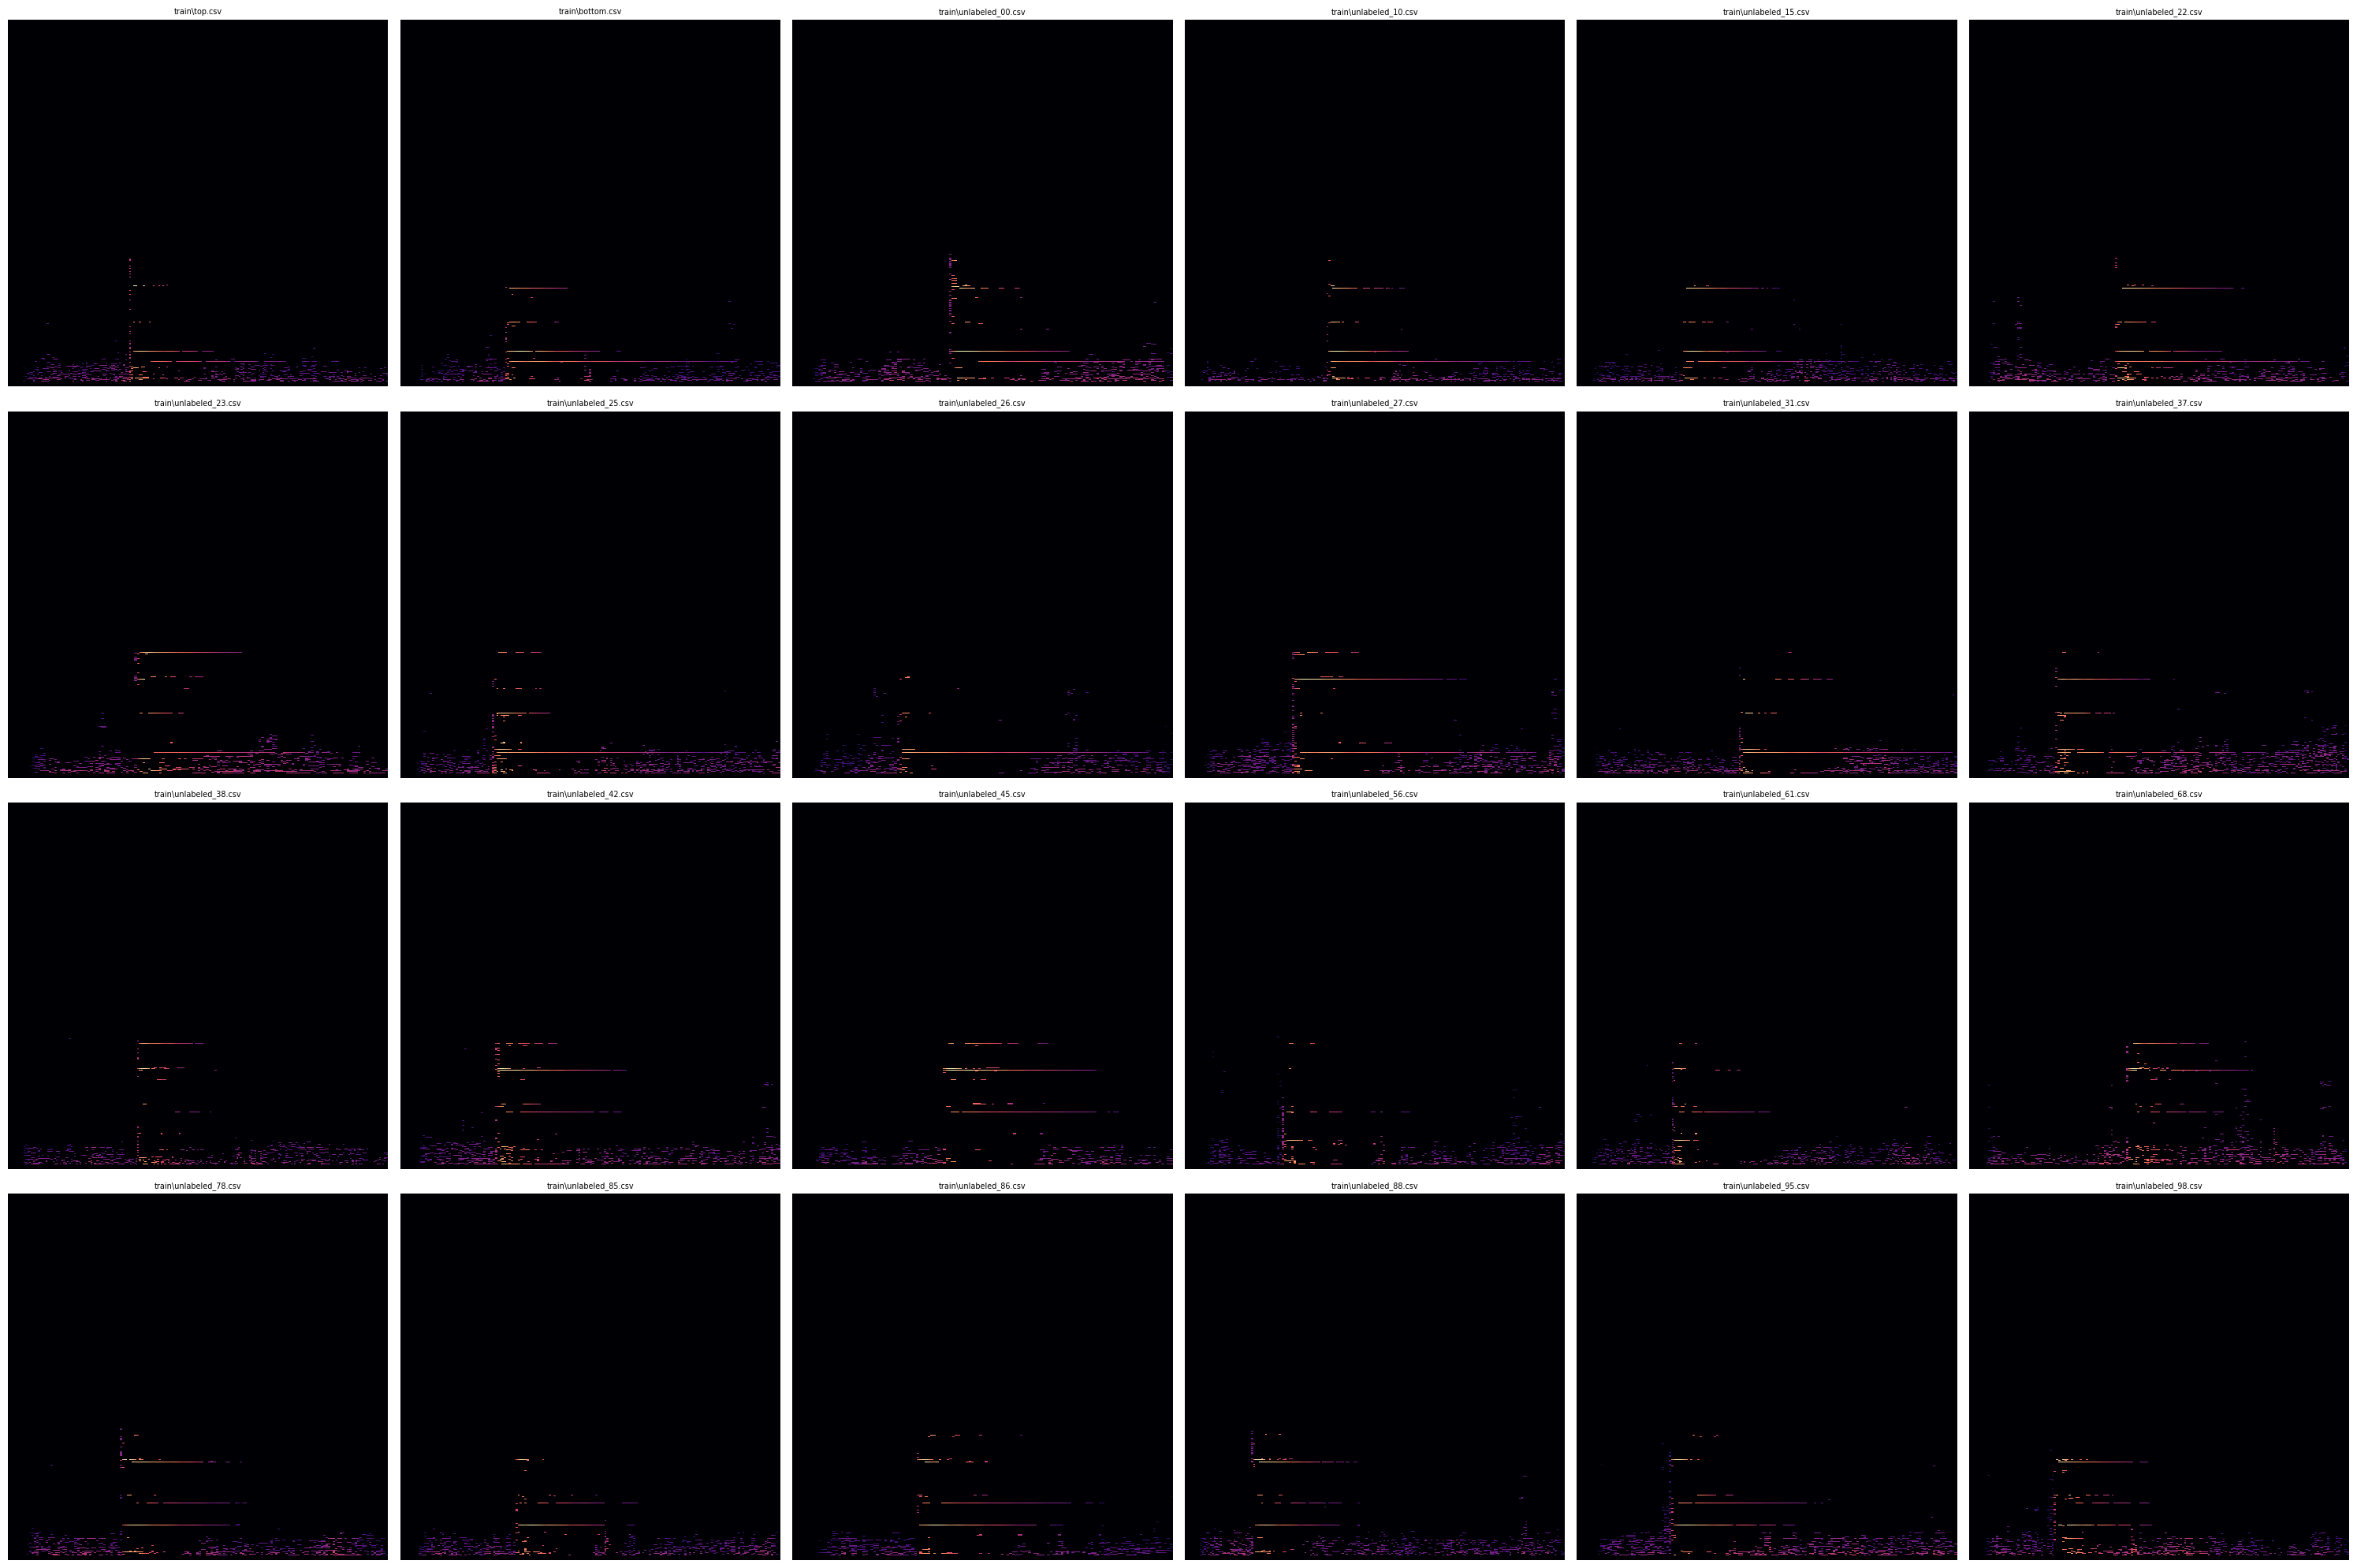

In [21]:
import glob

file_paths = ['train\\top.csv', 'train\\bottom.csv'] + sorted(glob.glob('train\\unlabeled_*.csv'))

fig, axes = plt.subplots(4, 6, figsize=(6 * 5, 4 * 5))
axes = axes.flatten()

for ax, path in zip(axes, file_paths):
    df = pd.read_csv(path, index_col=0).astype(float)
    spect = df.values
    spect_db = librosa.amplitude_to_db(spect, ref=np.max)
    times = df.columns.astype(float)
    dt_ms = np.mean(np.diff(times))
    sr = 1000.0 / dt_ms
    hop_length = 1
    
    librosa.display.specshow(
        spect_db,
        sr=sr,
        hop_length=hop_length,
        x_axis='time',
        y_axis='hz',
        ax=ax
    )
    ax.set_title(path, fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Final Classification: Threshold Based Approach

We will classify each recording by identifying its strongest frequency (the peak of the average spectrum) and comparing that peak to the midpoint (2018.73779296875) between the top-strike (2971.58203125) and bottom-strike (1065.8935546875) peaks — assigning to whichever side it falls or returning `None` if it’s too close to the threshold of 20% (1637.600 to 2399.876). This is simple but for the sake of test, I am prioritizing completion over complexity. 

In [26]:
top_mean = top.mean(axis=1)
bottom_mean = bottom.mean(axis=1)
top_peak_hz = top_mean.idxmax()
bottom_peak_hz = bottom_mean.idxmax()
top_peak_hz, bottom_peak_hz

(2971.58203125, 1065.8935546875)

In [27]:
threshold_hz = (top_peak_hz + bottom_peak_hz) / 2
margin = abs(top_peak_hz - bottom_peak_hz) * 0.2

In [28]:
threshold_hz, margin

(2018.73779296875, 381.1376953125)

We will **hardcode** the above value in the `water_bottle_challenge.py` file. Not a good idea. But will do for now. 

In [29]:
from water_bottle_challenge import classify_preprocessed_audio

unlabeled_paths = sorted(glob.glob('train\\unlabeled_*.csv'))
for path in unlabeled_paths:
    print(classify_preprocessed_audio(path))

1065.8935546875
1
1065.8935546875
1
1065.8935546875
1
2960.8154296875
0
2960.8154296875
0
1065.8935546875
1
1065.8935546875
1
2971.58203125
0
1065.8935546875
1
1065.8935546875
1
2960.8154296875
0
2971.58203125
0
2971.58203125
0
1065.8935546875
1
1065.8935546875
1
1065.8935546875
1
2960.8154296875
0
1065.8935546875
1
1065.8935546875
1
2960.8154296875
0
2971.58203125
0
1065.8935546875
1
